<a href="https://colab.research.google.com/github/rmani10063/metadrive-insight/blob/main/Smart_Health.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd

file_path = "/content/drive/MyDrive/Smart Ring/hr_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully ✅")
print(df.head())

Dataset Loaded Successfully ✅
   day   time  hour  heart_rate label
0    1  00:00     0          57   Low
1    1  00:30     0          53   Low
2    1  01:00     1          57   Low
3    1  01:30     1          57   Low
4    1  02:00     2          56   Low


In [5]:
print(df.info())
print(df.describe())
print(df['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   day         1440 non-null   int64 
 1   time        1440 non-null   object
 2   hour        1440 non-null   int64 
 3   heart_rate  1440 non-null   int64 
 4   label       1440 non-null   object
dtypes: int64(3), object(2)
memory usage: 56.4+ KB
None
               day         hour   heart_rate
count  1440.000000  1440.000000  1440.000000
mean     15.500000    11.500000    79.888889
std       8.658448     6.924591    18.302497
min       1.000000     0.000000    49.000000
25%       8.000000     5.750000    62.000000
50%      15.500000    11.500000    80.000000
75%      23.000000    17.250000    96.000000
max      30.000000    23.000000   117.000000
label
Normal    880
Low       319
High      241
Name: count, dtype: int64


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

X = df[['hour', 'heart_rate']]
y = df['label_encoded']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", len(X_train))
print("Testing size:", len(X_test))

Training size: 1152
Testing size: 288


In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)

model.fit(X_train, y_train)

print("Model Training Completed ✅")

Model Training Completed ✅


In [11]:
# Install TensorFlow (run once if needed)
!pip install tensorflow

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Convert labels to categorical
y_train_nn = tf.keras.utils.to_categorical(y_train)
y_test_nn = tf.keras.utils.to_categorical(y_test)

# Build Model
model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(2,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train with epochs
history = model.fit(
    X_train, y_train_nn,
    epochs=50,
    validation_data=(X_test, y_test_nn)
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4297 - loss: 3.0219 - val_accuracy: 0.4167 - val_loss: 0.9830
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6068 - loss: 0.8723 - val_accuracy: 0.7118 - val_loss: 0.7535
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6510 - loss: 0.8070 - val_accuracy: 0.7326 - val_loss: 0.7174
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6840 - loss: 0.7846 - val_accuracy: 0.7326 - val_loss: 0.6991
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7153 - loss: 0.7616 - val_accuracy: 0.7188 - val_loss: 0.6796
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7040 - loss: 0.7505 - val_accuracy: 0.7778 - val_loss: 0.6783
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7222 - loss: 0.7331 - val_accuracy: 0.7743 - val_loss: 0.6573
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7292 - loss: 0.7098 - val_accuracy: 0.7326 - val_loss: 0.6442
E

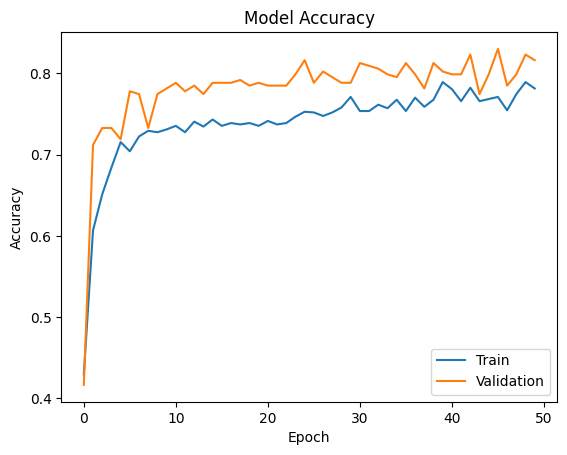

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

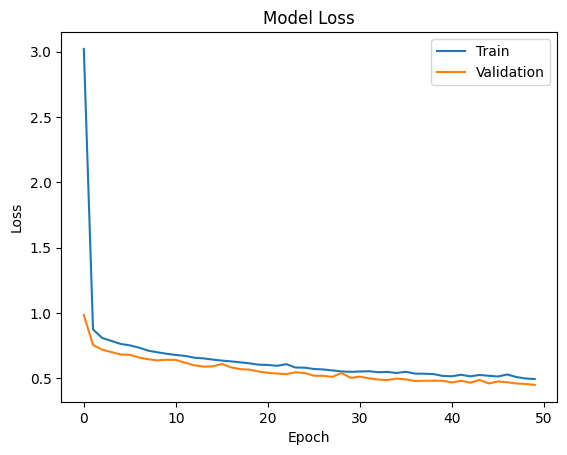

In [15]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

In [18]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# Get predictions (probabilities)
y_pred = model.predict(X_test)

# Convert probabilities → class index
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert one-hot y_test → class index
y_test_classes = np.argmax(y_test_nn, axis=1)

# Accuracy
accuracy = accuracy_score(y_test_classes, y_pred_classes)

print("Accuracy:", accuracy)

# Report
print("\nClassification Report:\n",
      classification_report(y_test_classes, y_pred_classes))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Accuracy: 0.8159722222222222

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.12      0.21        42
           1       0.87      0.84      0.85        55
           2       0.80      0.96      0.87       191

    accuracy                           0.82       288
   macro avg       0.89      0.64      0.65       288
weighted avg       0.84      0.82      0.77       288



In [31]:
def smart_heart_analysis(hour, hr):
    import numpy as np

    print("\n🫀 HEART RATE ANALYSIS RESULT\n")

    # ✅ RULE-BASED OVERRIDE (VERY IMPORTANT)
    if hr < 60:
        label = "Low"
    elif hr > 100:
        label = "High"
    else:
        # Only use model for normal range refinement
        pred = model.predict(np.array([[hour, hr]]))
        index = np.argmax(pred)
        label = le.inverse_transform([index])[0]

    # ===== OUTPUT =====
    if label == "Normal":
        print("✅ STATUS: NORMAL (Healthy)")
        print("\n✔ Meaning:")
        print("- Your heart rate is within a healthy range")

        print("\n💡 Tips:")
        print("- Maintain regular exercise")
        print("- Keep good sleep cycle")
        print("- Stay hydrated")

    elif label == "High":
        print("⚠️ STATUS: HIGH HEART RATE")

        print("\n🔍 Possible Reasons:")
        print("- Stress / Anxiety")
        print("- Physical exertion")
        print("- High caffeine intake")

        print("\n💡 Tips to Control:")
        print("- Sit and relax immediately")
        print("- Do deep breathing")
        print("- Drink water")
        print("- If persists, consult doctor")

    else:
        print("⚠️ STATUS: LOW HEART RATE")

        print("\n🔍 Possible Reasons:")
        print("- Fatigue / weakness")
        print("- Low energy levels")

        print("\n💡 Tips to Improve:")
        print("- Eat nutritious food")
        print("- Stay active")
        print("- Avoid long inactivity")

    print("\n-----------------------------------")

In [36]:
hour, hr = get_user_input()

if hour is not None:
    smart_heart_analysis(hour, hr)

Enter Hour (0–23): 5
Enter Heart Rate: 30

🫀 HEART RATE ANALYSIS RESULT

⚠️ STATUS: LOW HEART RATE

🔍 Possible Reasons:
- Fatigue / weakness
- Low energy levels

💡 Tips to Improve:
- Eat nutritious food
- Stay active
- Avoid long inactivity

-----------------------------------


In [37]:
def smart_heart_analysis(hour, hr):
    import numpy as np

    print("\n🫀 HEART RATE ANALYSIS RESULT\n")

    # Rule-based override
    if hr < 60:
        label = "Low"
    elif hr > 100:
        label = "High"
    else:
        pred = model.predict(np.array([[hour, hr]]))
        index = np.argmax(pred)
        label = le.inverse_transform([index])[0]

    # ===== COLOR OUTPUT =====
    if label == "Normal":
        print("\033[92m")  # Green
        print("✅ ✔ NORMAL STATUS ✔")
        print("💚 Healthy Heart Condition")
        print("\033[0m")

    elif label == "High":
        print("\033[91m")  # Red
        print("🚨 ⚠ HIGH HEART RATE ALERT ⚠ 🚨")

        if hr > 140:
            print("🔥 CRITICAL CONDITION 🔥")

        print("\033[0m")

    else:
        print("\033[93m")  # Yellow
        print("⚠ LOW HEART RATE WARNING ⚠")
        print("💛 Needs Attention")
        print("\033[0m")

    # ===== DETAILS =====
    if label == "High":
        print("\n🔍 Reasons:")
        print("- Stress / Anxiety")
        print("- Physical exertion")
        print("- High caffeine")

        print("\n💡 Tips:")
        print("- Sit & relax")
        print("- Deep breathing")
        print("- Drink water")

    elif label == "Low":
        print("\n🔍 Reasons:")
        print("- Weakness / fatigue")

        print("\n💡 Tips:")
        print("- Eat properly")
        print("- Stay active")

    else:
        print("\n💡 Maintain your healthy lifestyle!")

    print("\n-----------------------------------")

In [43]:
hour, hr = get_user_input()

if hour is not None:
    smart_heart_analysis(hour, hr)

Enter Hour (0–23): 4
Enter Heart Rate: 120

🫀 HEART RATE ANALYSIS RESULT


🚨 ⚠ HIGH HEART RATE ALERT ⚠ 🚨


🔍 Reasons:
- Stress / Anxiety
- Physical exertion
- High caffeine

💡 Tips:
- Sit & relax
- Deep breathing
- Drink water

-----------------------------------
